# Annealed LogZ Active Ablation Comparison

This notebook pulls the annealed-logZ ablation runs from W&B instead of the local `ablation_runs/` folder. It filters by the `annealed-logz` tag, prints the final train/test errors and active-train error for each W&B run, and compares them against the base run in W&B identified by `runs/20260426_084857_fmnist`.

In [5]:
from pathlib import Path
import json
import math

import pandas as pd
import matplotlib.pyplot as plt
import wandb
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')

ROOT = Path('.')
PROJECT = 'maxent-feasible-fmnist'
ABLATION_TAG = 'annealed-logz'
BASE_RUN_DIR = 'runs/20260426_084857_fmnist'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

In [6]:
def summary_value(summary, candidates, default=None):
    for key in candidates:
        try:
            value = summary.get(key)
        except Exception:
            value = None
        if value is not None:
            return value
    return default


def run_metrics(run):
    summary = run.summary

    train_acc = summary_value(summary, ['final/train_acc', 'final/final_train_acc'])
    test_acc = summary_value(summary, ['final/test_acc', 'final/final_test_acc'])

    train_error = summary_value(summary, ['final/train_error', 'final/final_train_error'])
    if train_error is None and train_acc is not None:
        train_error = 1.0 - float(train_acc)

    test_error = summary_value(summary, ['final/test_error', 'final/final_test_error'])
    if test_error is None and test_acc is not None:
        test_error = 1.0 - float(test_acc)

    return {
        'source': 'run',
        'run_name': run.name,
        'run_id': run.id,
        'state': run.state,
        'group': run.group,
        'output_dir': run.config.get('output_dir'),
        'train_acc': None if train_acc is None else float(train_acc),
        'test_acc': None if test_acc is None else float(test_acc),
        'active_train_error': summary_value(summary, ['final/active_train_error', 'final/final_active_train_error']),
        'train_error': None if train_error is None else float(train_error),
        'test_error': None if test_error is None else float(test_error),
        'train_violation': summary_value(summary, ['final/train_violation', 'final/final_train_violation']),
        'test_violation': summary_value(summary, ['final/test_violation', 'final/final_test_violation']),
        'active_train_violation': summary_value(summary, ['final/active_train_violation', 'final/final_active_train_violation']),
        'pac_bayes_error_bound': summary_value(summary, ['final/pac_bayes_bound', 'final/final_pac_bayes_bound']),
        'logz_ti': summary_value(summary, ['final/final_logZ_TI', 'final/logZ_TI']),
    }


def find_base_run(api, project_path, base_run_dir):
    for run in api.runs(project_path):
        try:
            if run.config.get('run_dir') == base_run_dir:
                return run
        except Exception:
            continue
    raise FileNotFoundError(f'Could not find base run with run_dir={base_run_dir!r} in {project_path}')


def gather_ablation_runs(api, project_path, tag):
    rows = []
    for run in api.runs(project_path, filters={'tags': {'$in': [tag]}}):
        if run.state != 'finished':
            continue

        row = run_metrics(run)
        row['source'] = 'ablation'
        rows.append(row)

    if len(rows) == 0:
        raise FileNotFoundError(f'No finished W&B runs found with tag={tag!r} in {project_path}')

    df = pd.DataFrame(rows)
    if 'run_id' in df.columns:
        df = df.drop_duplicates(subset=['run_id']).reset_index(drop=True)
    return df


api = wandb.Api()
project_path = f'{api.default_entity}/{PROJECT}'
base_run = find_base_run(api, project_path, BASE_RUN_DIR)
base_metrics = run_metrics(base_run)
base_metrics['source'] = 'base_run'
base_metrics['wandb_url'] = base_run.url
base_metrics['run_dir'] = BASE_RUN_DIR

ablation_df = gather_ablation_runs(api, project_path, ABLATION_TAG)
ablation_df['delta_train_error_vs_base'] = ablation_df['train_error'] - base_metrics['train_error']
ablation_df['delta_test_error_vs_base'] = ablation_df['test_error'] - base_metrics['test_error']

base_metrics

{'source': 'base_run',
 'run_name': 'fmnist',
 'run_id': '1utxjgg5',
 'state': 'finished',
 'group': 'debug',
 'output_dir': 'runs',
 'train_acc': 0.9714666666666668,
 'test_acc': 0.9069,
 'active_train_error': None,
 'train_error': 0.02853333333333319,
 'test_error': 0.09309999999999996,
 'train_violation': 0.05821666494011879,
 'test_violation': 0.13130000233650208,
 'active_train_violation': None,
 'pac_bayes_error_bound': 0.16966704043605732,
 'logz_ti': None,
 'wandb_url': 'https://wandb.ai/alelab/maxent-feasible-fmnist/runs/1utxjgg5',
 'run_dir': 'runs/20260426_084857_fmnist'}

/tmp/ipykernel_4064965/1059035345.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary_df = pd.concat([


,source,run_name,run_id,state,group,output_dir,active_train_error,train_error,test_error,train_violation,test_violation,active_train_violation,pac_bayes_error_bound,delta_train_error_vs_base,delta_test_error_vs_base
0,base_run,fmnist,1utxjgg5,finished,debug,runs,NaN,0.028533,0.0931,0.058217,0.1313,NaN,0.169667,NaN,NaN
1,ablation,20260426_084857_fmnist-0,1t7rzvod,finished,None,ablation_runs/annealed_logz_active,0.508401,0.412717,0.4138,1.000000,1.0000,1.000000,NaN,0.384183,0.3207
2,ablation,20260426_084857_fmnist-0,aqoa8jgz,finished,None,ablation_runs/fixed_beta1_active,0.605505,0.669683,0.6711,0.915533,0.9174,0.922829,NaN,0.641150,0.5780
3,ablation,20260426_084857_fmnist-0,brr93wty,finished,None,ablation_runs/fixed_beta1_active,0.461130,0.429750,0.4347,0.978633,0.9787,0.986521,NaN,0.401217,0.3416
4,ablation,20260426_084857_fmnist-1,0xa1d96f,finished,None,ablation_runs/fixed_beta1_active,0.523683,0.483517,0.4847,0.999983,1.0000,0.999905,NaN,0.454983,0.3916
5,ablation,20260426_084857_fmnist-2,ata1blba,finished,None,ablation_runs/fixed_beta1_active,0.702421,0.761933,0.7637,0.936550,0.9404,0.910584,NaN,0.733400,0.6706
6,ablation,20260426_084857_fmnist-3,t1eayo9i,finished,None,ablation_runs/fixed_beta1_active,0.564404,0.577933,0.5847,1.000000,1.0000,1.000000,NaN,0.549400,0.4916
7,ablation,20260426_084857_fmnist-4,cwzrnmkj,finished,None,ablation_runs/fixed_beta1_active,0.609872,0.660217,0.6626,0.941183,0.9469,0.910774,NaN,0.631683,0.5695


Found 7 finished W&B runs tagged 'annealed-logz'.
Base run:
  run_name=fmnist
  train_error=0.028533
  test_error=0.093100
  active_train_error=None
Saved comparison table to: ablation_runs/annealed_logz_active/wandb_annealed_logz_active_comparison.csv
Saved plot to: ablation_runs/annealed_logz_active/wandb_annealed_logz_active_comparison.png


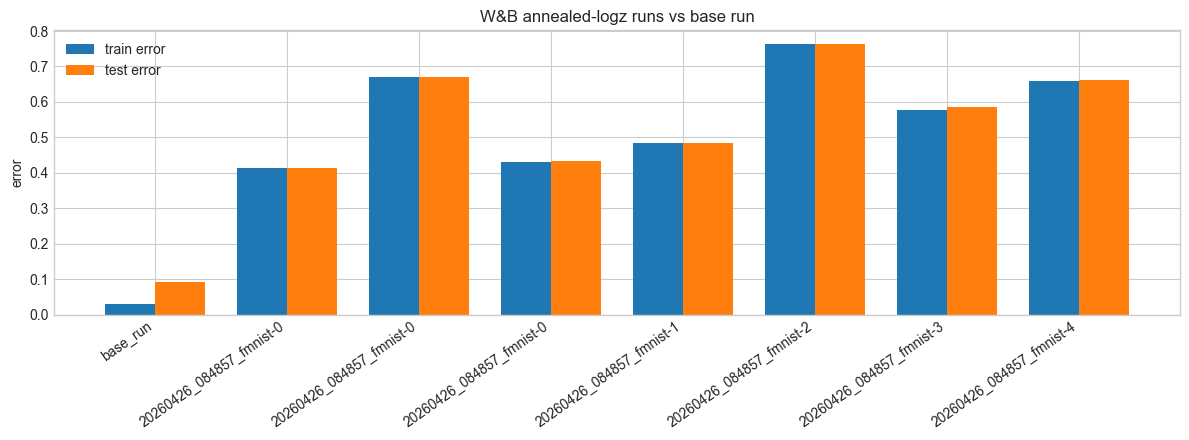

In [7]:
comparison_df = ablation_df.copy()
comparison_df = comparison_df.sort_values(['run_name', 'run_id']).reset_index(drop=True)

summary_df = pd.concat([
    pd.DataFrame([base_metrics]),
    comparison_df,
], ignore_index=True, sort=False)

columns = [
    'source',
    'run_name',
    'run_id',
    'state',
    'group',
    'output_dir',
    'active_train_error',
    'train_error',
    'test_error',
    'train_violation',
    'test_violation',
    'active_train_violation',
    'pac_bayes_error_bound',
    'delta_train_error_vs_base',
    'delta_test_error_vs_base',
]
summary_df = summary_df.reindex(columns=[c for c in columns if c in summary_df.columns])

display(summary_df)

print(f"Found {len(ablation_df)} finished W&B runs tagged '{ABLATION_TAG}'.")
print('Base run:')
print(f"  run_name={base_metrics['run_name']}")
print(f"  train_error={base_metrics['train_error']:.6f}")
print(f"  test_error={base_metrics['test_error']:.6f}")
print(f"  active_train_error={base_metrics['active_train_error']}")

fig, ax = plt.subplots(figsize=(12, 4.5))
plot_df = pd.concat([
    pd.DataFrame([{
        'label': 'base_run',
        'train_error': base_metrics['train_error'],
        'test_error': base_metrics['test_error'],
    }]),
    comparison_df[['run_name', 'train_error', 'test_error']].rename(columns={'run_name': 'label'}),
], ignore_index=True)

x = list(range(len(plot_df)))
width = 0.38
ax.bar([i - width / 2 for i in x], plot_df['train_error'].tolist(), width=width, label='train error')
ax.bar([i + width / 2 for i in x], plot_df['test_error'].tolist(), width=width, label='test error')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['label'].tolist(), rotation=35, ha='right')
ax.set_ylabel('error')
ax.set_title('W&B annealed-logz runs vs base run')
ax.legend()
plt.tight_layout()

out_csv = ROOT / 'ablation_runs' / 'annealed_logz_active' / 'wandb_annealed_logz_active_comparison.csv'
summary_df.to_csv(out_csv, index=False)
print(f'Saved comparison table to: {out_csv}')

out_png = ROOT / 'ablation_runs' / 'annealed_logz_active' / 'wandb_annealed_logz_active_comparison.png'
fig.savefig(out_png, dpi=200)
print(f'Saved plot to: {out_png}')
plt.show()

,source,active_train_error,train_error,test_error,train_violation,test_violation
0,base_run,NaN,0.028533,0.0931,0.058217,0.1313
1,chain_000_anneal_rows,0.508401,0.412717,0.4138,1.000000,1.0000


Saved comparison table to: ablation_runs/annealed_logz_active/annealed_logz_active_final_comparison.csv
Saved plot to: ablation_runs/annealed_logz_active/annealed_logz_active_final_comparison.png


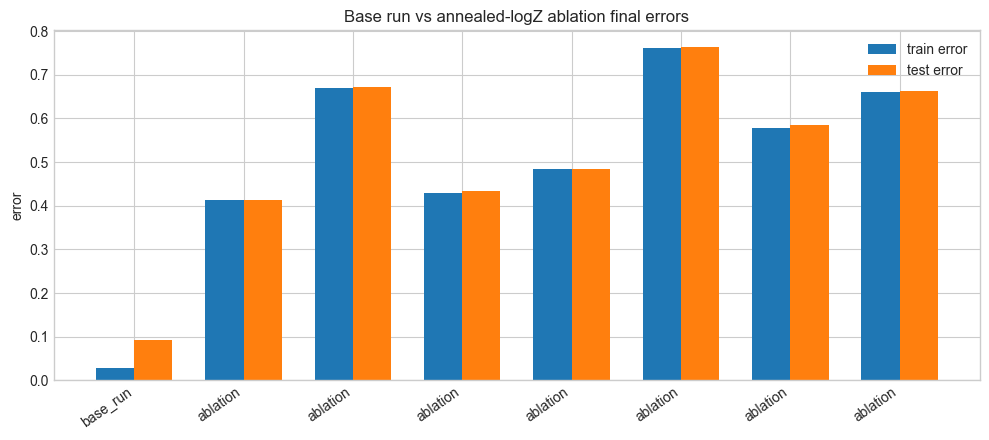

In [ ]:
display(summary_df)

plot_df = pd.concat([
    pd.DataFrame([{
        'label': 'base_run',
        'train_error': base_metrics['train_error'],
        'test_error': base_metrics['test_error'],
    }]),
    comparison_df.assign(
        label=comparison_df['run_name'].astype(str) + ' [' + comparison_df['output_dir'].fillna('unknown').astype(str) + ']'
    )[['label', 'train_error', 'test_error']],
], ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 4.5))
x = list(range(len(plot_df)))
width = 0.38
ax.bar([i - width / 2 for i in x], plot_df['train_error'].tolist(), width=width, label='train error')
ax.bar([i + width / 2 for i in x], plot_df['test_error'].tolist(), width=width, label='test error')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['label'].tolist(), rotation=35, ha='right')
ax.set_ylabel('error')
ax.set_title('W&B annealed-logz runs vs base run')
ax.legend()
plt.tight_layout()

out_csv = ROOT / 'ablation_runs' / 'annealed_logz_active' / 'wandb_annealed_logz_active_comparison.csv'
summary_df.to_csv(out_csv, index=False)
print(f'Saved comparison table to: {out_csv}')

out_png = ROOT / 'ablation_runs' / 'annealed_logz_active' / 'wandb_annealed_logz_active_comparison.png'
fig.savefig(out_png, dpi=200)
print(f'Saved plot to: {out_png}')
plt.show()

## Notes

- The notebook now pulls the annealed-logZ runs from W&B using the `annealed-logz` tag.
- The base run is identified in W&B by `run_dir = runs/20260426_084857_fmnist`.
- If you want to narrow the W&B query further, adjust `ABLATION_TAG` or add another filter in the `gather_ablation_runs` cell.
- The comparison table and plot are saved under `ablation_runs/annealed_logz_active/`.